In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
data = pd.read_csv("Train.csv")

In [3]:
print("First 5 rows of dataset:")
print(data.head())


First 5 rows of dataset:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44  

In [4]:
print("\nDataset Shape:", data.shape)


Dataset Shape: (10999, 12)


In [5]:
data = data.drop("ID", axis=1)

In [6]:
label_encoder = LabelEncoder()

categorical_columns = [
    "Warehouse_block",
    "Mode_of_Shipment",
    "Product_importance",
    "Gender"
]

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])


In [7]:
X = data.drop("Reached.on.Time_Y.N", axis=1)
y = data["Reached.on.Time_Y.N"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)



In [36]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("\nRandom Forest Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Random Forest Model Accuracy: 0.6668181818181819

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.70      0.63       895
           1       0.76      0.64      0.70      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200



In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.6668181818181819


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.70      0.63       895
           1       0.76      0.64      0.70      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200



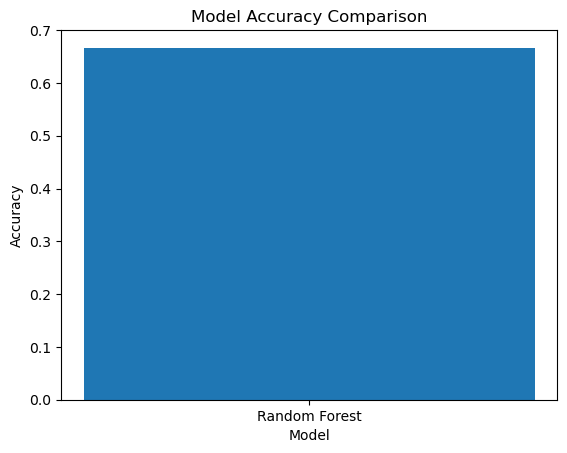

In [17]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

models = ["Random Forest"]
scores = [accuracy]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

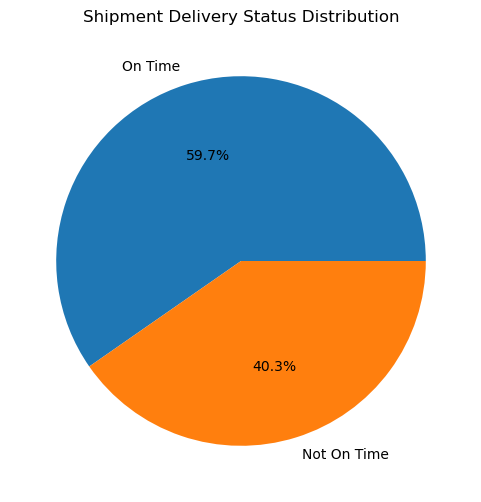

In [18]:
target_counts = data["Reached.on.Time_Y.N"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=["On Time", "Not On Time"],
    autopct='%1.1f%%'
)

plt.title("Shipment Delivery Status Distribution")

plt.show()

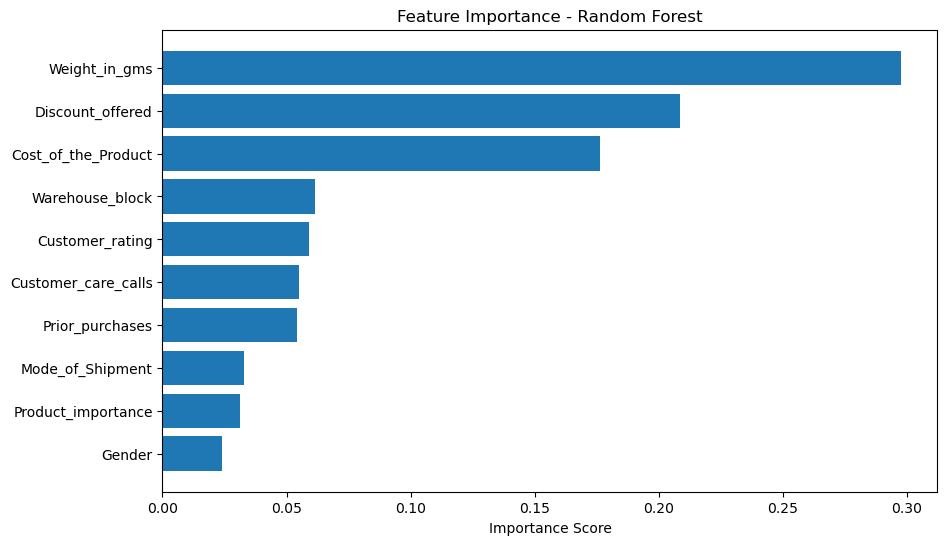

In [19]:
import pandas as pd

feature_importances = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

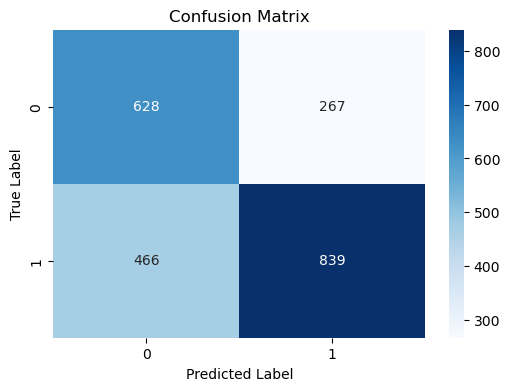

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

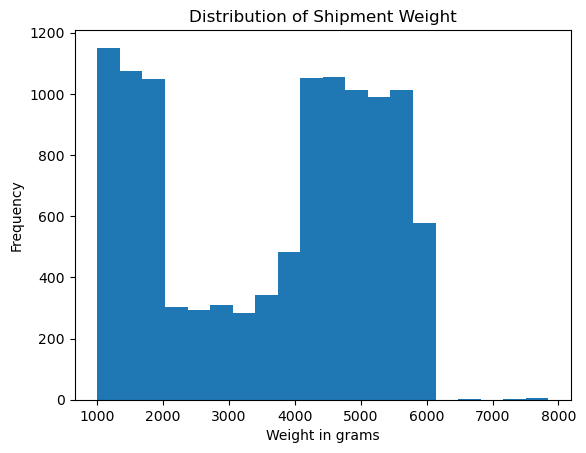

In [21]:
plt.hist(data["Weight_in_gms"], bins=20)

plt.title("Distribution of Shipment Weight")
plt.xlabel("Weight in grams")
plt.ylabel("Frequency")

plt.show()

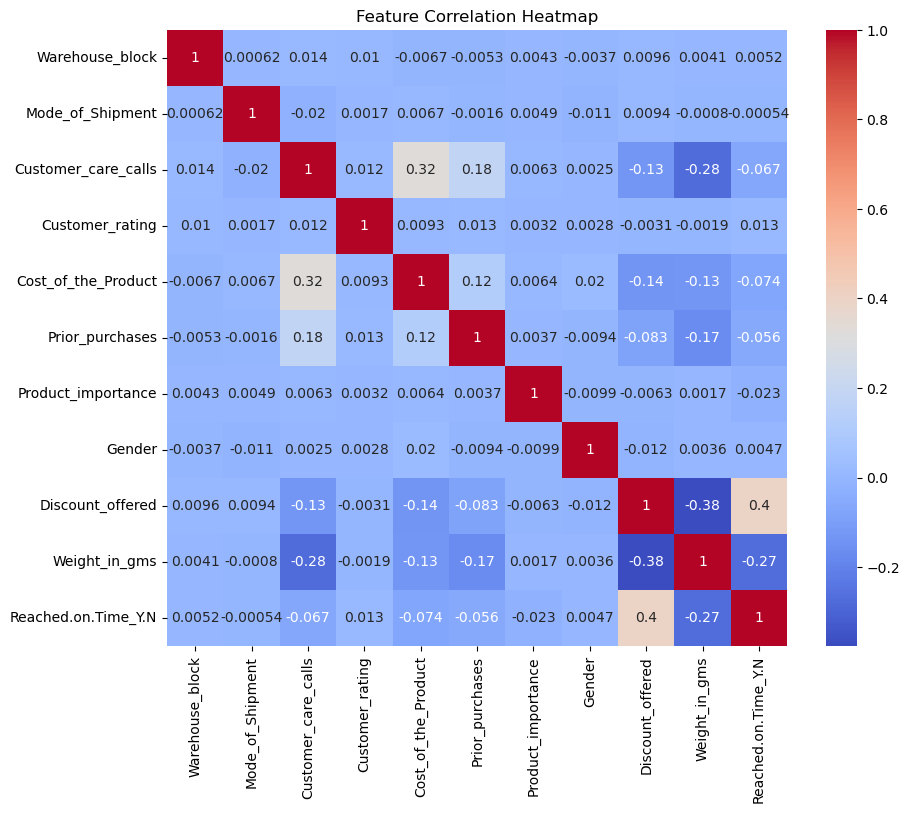

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

corr = data.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

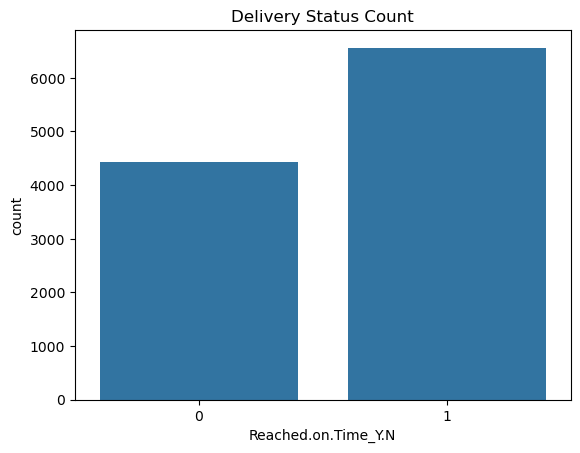

In [23]:
sns.countplot(x="Reached.on.Time_Y.N", data=data)

plt.title("Delivery Status Count")

plt.show()

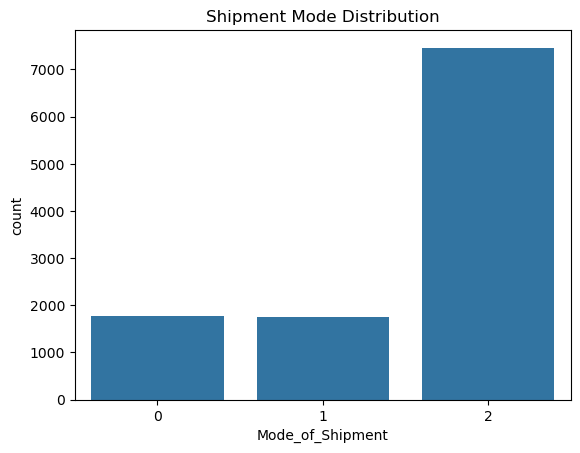

In [24]:
sns.countplot(x="Mode_of_Shipment", data=data)

plt.title("Shipment Mode Distribution")

plt.show()

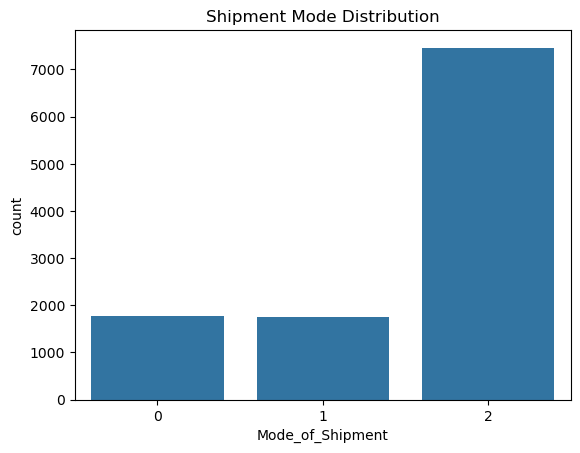

In [25]:
sns.countplot(x="Mode_of_Shipment", data=data)

plt.title("Shipment Mode Distribution")

plt.show()

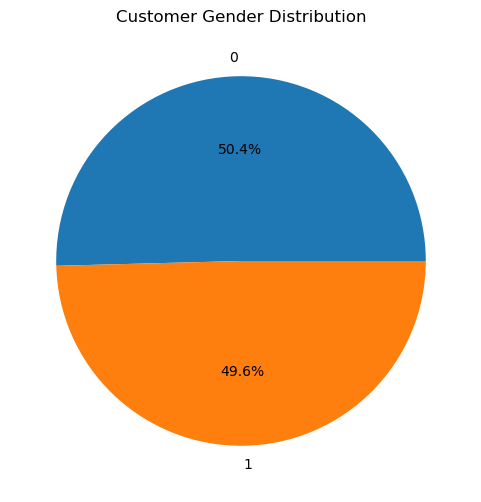

In [26]:
gender_counts = data["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")

plt.title("Customer Gender Distribution")

plt.show()

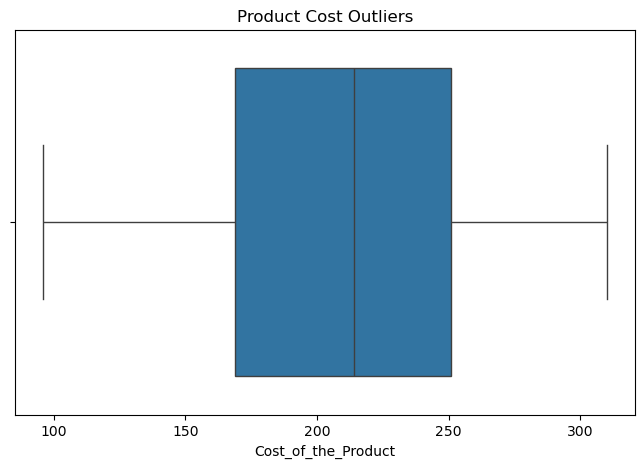

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data["Cost_of_the_Product"])

plt.title("Product Cost Outliers")

plt.show()

In [29]:
importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(by="Importance", ascending=False)

print(feature_df)

               Feature  Importance
9        Weight_in_gms    0.297498
8     Discount_offered    0.208433
4  Cost_of_the_Product    0.176517
0      Warehouse_block    0.061332
3      Customer_rating    0.058972
2  Customer_care_calls    0.054839
5      Prior_purchases    0.054295
1     Mode_of_Shipment    0.032969
6   Product_importance    0.031093
7               Gender    0.024052


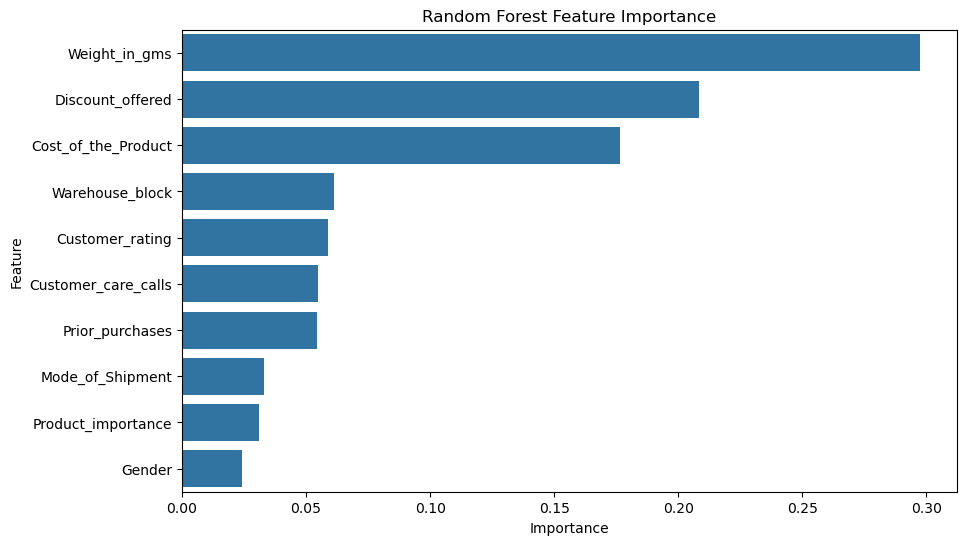

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=feature_df)

plt.title("Random Forest Feature Importance")

plt.show()

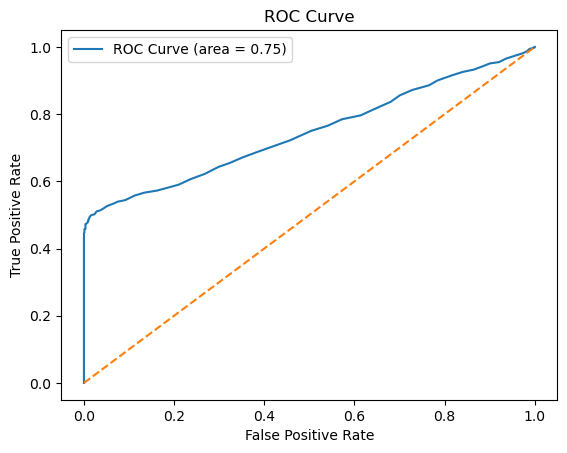

In [31]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC Curve (area = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [32]:
import pickle

with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully!")

Model saved successfully!
